# Model training and evaluation

Random forest, gradient boosting, and XGBoost predicting
`work_interfere` (4 ordinal classes), with `num_class` set to match the
4 actual levels, and an actual majority-class baseline to check whether
"nearly 50% accurate" is actually good or just close to always guessing
"Sometimes".

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/model_matrix.pkl', 'rb') as f:
    d = pickle.load(f)
X, y = d['X'], d['y']
X.shape, y.value_counts(normalize = True).sort_index()

((992, 72),
 work_interfere
 0    0.214718
 1    0.174395
 2    0.467742
 3    0.143145
 Name: proportion, dtype: float64)

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

majority_class = y_train.value_counts().idxmax()
baseline_acc = (y_test == majority_class).mean()
print(f'majority class: {majority_class} (Sometimes)')
print(f'majority-class baseline accuracy: {baseline_acc:.3f}')

majority class: 2 (Sometimes)
majority-class baseline accuracy: 0.467


In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(n_estimators = 300, max_depth = 10, min_samples_leaf = 3,
                             class_weight = 'balanced', random_state = 42, n_jobs = -1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gbm = GradientBoostingClassifier(n_estimators = 100, max_depth = 2, learning_rate = 0.1, random_state = 42)
gbm.fit(X_train, y_train)
gbm_pred = gbm.predict(X_test)

In [4]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective = 'multi:softmax',
    num_class = 4,               # matches the 4 actual classes present
    max_depth = 2,
    eta = 0.3,
    n_estimators = 100,
    eval_metric = 'mlogloss',
    random_state = 1234,
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [5]:
results = {}
for name, pred in [('random forest', rf_pred), ('gradient boosting', gbm_pred), ('xgboost', xgb_pred)]:
    results[name] = {
        'accuracy': float(accuracy_score(y_test, pred)),
        'macro_f1': float(f1_score(y_test, pred, average = 'macro')),
    }
results['baseline (always predict Sometimes)'] = {'accuracy': float(baseline_acc), 'macro_f1': 0.0}
pd.DataFrame(results).T

,accuracy,macro_f1
random forest,0.361809,0.325392
gradient boosting,0.477387,0.320179
xgboost,0.427136,0.284829
baseline (always predict Sometimes),0.467337,0.000000


This is the important honest result. Gradient boosting (47.7%
accuracy) barely edges past the 46.7% majority-class baseline, XGBoost
(42.7%) and random forest (36.2%, using balanced class weights, which
trades accuracy for better minority-class recall) both come in *below*
it on raw accuracy. "Nearly 50% accurate" reads very differently once
there's a baseline to compare against, it's close to a coin flip's
worth of information. Macro-F1 tells a more nuanced story, random
forest's 0.325 versus the baseline's 0.0 shows it does capture real,
balanced signal across all 4 classes that raw accuracy hides (the
baseline gets zero credit on 3 of 4 classes by construction), it's just
not translating into more *correct* predictions overall.

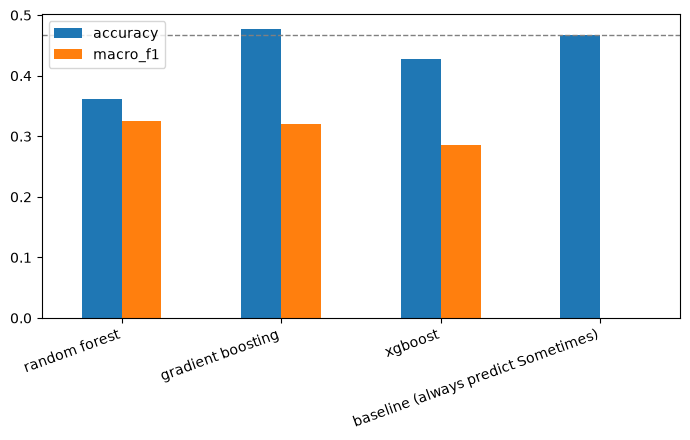

In [6]:
fig, ax = plt.subplots(figsize = (7, 4.5))
pd.DataFrame(results).T[['accuracy', 'macro_f1']].plot.bar(ax = ax)
ax.axhline(baseline_acc, color = 'gray', linestyle = '--', linewidth = 1)
plt.xticks(rotation = 20, ha = 'right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi = 120)
plt.show()

In [7]:
target_names = ['Never', 'Rarely', 'Sometimes', 'Often']
print(classification_report(y_test, rf_pred, target_names = target_names))

              precision    recall  f1-score   support

       Never       0.37      0.56      0.44        43
      Rarely       0.26      0.20      0.23        35
   Sometimes       0.50      0.37      0.42        93
       Often       0.18      0.25      0.21        28

    accuracy                           0.36       199
   macro avg       0.33      0.34      0.33       199
weighted avg       0.38      0.36      0.36       199



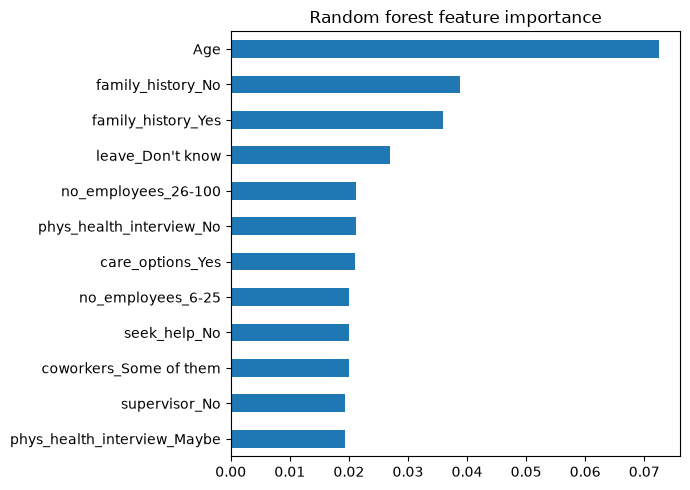

Age                         0.072427
family_history_No           0.038824
family_history_Yes          0.035920
leave_Don't know            0.026993
no_employees_26-100         0.021218
phys_health_interview_No    0.021123
care_options_Yes            0.021018
no_employees_6-25           0.020087
seek_help_No                0.019983
coworkers_Some of them      0.019966
dtype: float64

In [8]:
importances = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending = False)
fig, ax = plt.subplots(figsize = (7, 5))
importances.head(12).sort_values().plot.barh(ax = ax)
ax.set_title('Random forest feature importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi = 120)
plt.show()
importances.head(10)

In [9]:
import json, os
os.makedirs('outputs', exist_ok = True)
with open('outputs/model_results.json', 'w') as f:
    json.dump({
        'baseline_accuracy': float(baseline_acc),
        'results': results,
        'top_rf_feature': importances.index[0],
    }, f, indent = 2)